In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r'data\titanic_limpio.csv')

In [3]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Tiene_cabina
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Sin Datos,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1


### EDA ( Exploratory Data Analysis)

In [4]:
type(df['Age'].values[0]) # Saber el tipo de dato de una columna concreta

numpy.float64

In [5]:
df['Age'].shape

(891,)

In [6]:
edad = df['Age']
np.mean(edad) # Media de la columna edad

np.float64(29.36158249158249)

In [7]:
np.std(round(edad, 2)) # Desviación típica de la columna edad


np.float64(13.012388272793666)

In [8]:
np.round(np.mean(edad), 2) # solving 

np.float64(29.36)

In [9]:
np.min(edad) # Edad mínima

np.float64(0.42)

In [10]:
resultado_formateado = f"{np.std(edad):.2f}"
resultado_formateado

'13.01'

In [11]:
np.max(edad) # Edad máxima

np.float64(80.0)

<Axes: xlabel='Fare', ylabel='Count'>

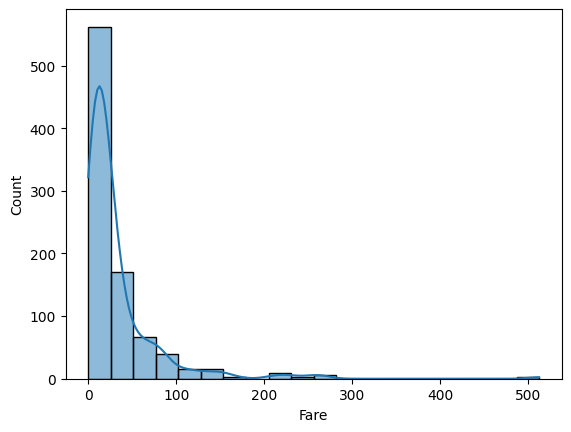

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(tarifa, bins=20, kde=True) # Histograma de la edad

<Axes: xlabel='Fare'>

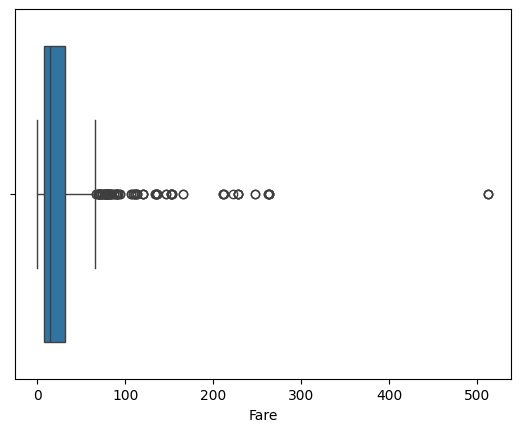

In [17]:
sns.boxplot(x=tarifa) # Boxplot de la edad

In [16]:
tarifa = df['Fare']

In [19]:
percentiles = np.percentile(tarifa, [25, 50, 75])
percentiles # Percentiles 25, 50 y 75 de la edad

array([ 7.9104, 14.4542, 31.    ])

### Analisis supervivencia 

In [20]:
df['Survived'].value_counts() # Conteo de supervivientes

Survived
0    549
1    342
Name: count, dtype: int64

In [21]:
df['Survived'].mean() * 100

np.float64(38.38383838383838)

In [22]:
tabla_clase = df.groupby('Pclass')['Survived'].agg(['count', 'mean', 'sum'])
tabla_clase.columns = ['Conteo', 'Media', 'Supervivientes']
tabla_clase['Tasa'] = tabla_clase['Media'] * 100
tabla_clase = tabla_clase.sort_index()
tabla_clase

,Conteo,Media,Supervivientes,Tasa
Pclass,,,,
1,216,0.629630,136,62.962963
2,184,0.472826,87,47.282609
3,491,0.242363,119,24.236253


In [23]:
tabla_clase = df.groupby('Sex')['Survived'].agg(['count', 'sum', 'mean'])
tabla_clase.columns = ['Total', 'Sobrevivieron', 'Tasa']
tabla_clase['Tasa'] = tabla_clase['Tasa'] * 100
tabla_clase = tabla_clase.sort_index()
tabla_clase

,Total,Sobrevivieron,Tasa
Sex,,,
female,314,233,74.203822
male,577,109,18.890815


In [26]:
hombres_primera_clase = df[(df['Sex'] == 'male') & (df['Pclass'] == 1)]


In [27]:
hombres_primera_clase

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Tiene_cabina
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,1
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S,1
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S,1
30,31,0,1,"Uruchurtu, Don. Manuel E",male,40.0,0,0,PC 17601,27.7208,Sin Datos,C,0
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,Sin Datos,C,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
839,840,1,1,"Marechal, Mr. Pierre",male,28.0,0,0,11774,29.7000,C47,C,1
857,858,1,1,"Daly, Mr. Peter Denis",male,51.0,0,0,113055,26.5500,E17,S,1
867,868,0,1,"Roebling, Mr. Washington Augustus II",male,31.0,0,0,PC 17590,50.4958,A24,S,1
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S,1


In [29]:
ninos = df[(df['Age'] < 18)]

In [30]:
ninos

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Tiene_cabina
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,Sin Datos,S,0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,Sin Datos,C,0
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,1
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,Sin Datos,S,0
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,Sin Datos,Q,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,347082,31.2750,Sin Datos,S,0
852,853,0,3,"Boulos, Miss. Nourelain",female,9.0,1,1,2678,15.2458,Sin Datos,C,0
853,854,1,1,"Lines, Miss. Mary Conover",female,16.0,0,1,PC 17592,39.4000,D28,S,1
869,870,1,3,"Johnson, Master. Harold Theodor",male,4.0,1,1,347742,11.1333,Sin Datos,S,0


In [31]:
adultos_tercera_clase = df.query('Age >= 18 & Pclass == 3')

In [32]:
adultos_tercera_clase

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Tiene_cabina
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Sin Datos,S,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Sin Datos,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Sin Datos,S,0
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Sin Datos,Q,0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,Sin Datos,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,Sin Datos,S,0
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,Sin Datos,S,0
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,Sin Datos,Q,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,Sin Datos,S,0


In [34]:
df['Fare']

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

In [37]:
def categorizar_tarifa(Fare):
    if Fare < 10:
        return 'Baja'
    elif Fare < 50:
        return 'Media'
    else:
        return 'Alta'

In [41]:
df['tarifa_categoria'] = df['Fare'].apply(categorizar_tarifa)

In [42]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Tiene_cabina,tarifa_categoria
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Sin Datos,S,0,Baja
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,Alta
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Sin Datos,S,0,Baja
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,Alta
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Sin Datos,S,0,Baja
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,Sin Datos,S,0,Media
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,Media
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,Sin Datos,S,0,Media
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,Media
